In [ ]:
# install full version
!pip install pycaret[full]

In [ ]:
import pycaret
print(pycaret.__version__)

3.3.2


In [ ]:
import pandas as pd

student_data = pd.read_csv('./Students Performance Dataset.csv')

student_data.drop(columns=['Student_ID', 'First_Name', 'Last_Name', 'Email', 'Total_Score', 'Attendance (%)',
                           'Final_Score', 'Projects_Score'], inplace=True)
student_data.shape

(5000, 15)

In [ ]:
student_data.head()

,Gender,Age,Department,Midterm_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Grade,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,Parent_Education_Level,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night
0,Female,22,Mathematics,40.61,73.69,53.17,73.4,F,10.3,Yes,No,Master's,Medium,1,5.9
1,Male,18,Business,57.27,74.23,98.23,88.0,B,27.1,No,No,High School,Low,4,4.3
2,Male,24,Engineering,41.84,85.85,50.00,4.7,D,12.4,Yes,No,High School,Low,9,6.1
3,Female,24,Engineering,45.65,68.10,66.27,4.2,F,25.5,No,Yes,High School,Low,8,4.9
4,Female,23,CS,53.13,67.66,83.98,64.3,C,13.3,Yes,No,Master's,Medium,6,4.5


In [ ]:
student_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Gender                      5000 non-null   object 
 1   Age                         5000 non-null   int64  
 2   Department                  5000 non-null   object 
 3   Midterm_Score               5000 non-null   float64
 4   Assignments_Avg             5000 non-null   float64
 5   Quizzes_Avg                 5000 non-null   float64
 6   Participation_Score         5000 non-null   float64
 7   Grade                       5000 non-null   object 
 8   Study_Hours_per_Week        5000 non-null   float64
 9   Extracurricular_Activities  5000 non-null   object 
 10  Internet_Access_at_Home     5000 non-null   object 
 11  Parent_Education_Level      3975 non-null   object 
 12  Family_Income_Level         5000 non-null   object 
 13  Stress_Level (1-10)         5000 

In [ ]:
student_data = student_data[student_data['Grade'] != 'A']

In [ ]:
student_data['Grade'].value_counts()

,count
Grade,
C,2307
D,1760
B,638
F,279


In [ ]:
student_data.describe()

,Age,Midterm_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Study_Hours_per_Week,Stress_Level (1-10),Sleep_Hours_per_Night
count,4984.000000,4984.000000,4984.000000,4984.000000,4984.000000,4984.000000,4984.000000,4984.000000
mean,21.047753,70.636906,74.908740,74.797145,49.877769,17.517255,5.506421,6.513102
std,1.990981,17.421557,14.394863,14.422735,28.977807,7.196548,2.887127,1.446494
min,18.000000,40.000000,50.000000,50.000000,0.000000,5.000000,1.000000,4.000000
25%,19.000000,55.647500,62.327500,62.337500,25.000000,11.500000,3.000000,5.300000
50%,21.000000,70.730000,75.005000,74.820000,49.400000,17.400000,6.000000,6.500000
75%,23.000000,85.640000,87.230000,87.272500,75.425000,23.700000,8.000000,7.800000
max,24.000000,99.990000,99.990000,99.990000,100.000000,30.000000,10.000000,9.000000


In [ ]:
#cek missing value
student_data.isnull().sum()/student_data.shape[0]*100

,0
Gender,0.000000
Age,0.000000
Department,0.000000
Midterm_Score,0.000000
Assignments_Avg,0.000000
Quizzes_Avg,0.000000
Participation_Score,0.000000
Grade,0.000000
Study_Hours_per_Week,0.000000
Extracurricular_Activities,0.000000


TRAIN TEST SPLIT 80-20

In [ ]:
from sklearn.model_selection import train_test_split

X = student_data.drop(columns=['Grade'])
y = student_data['Grade']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    train_size=0.8,
    random_state=42,
    stratify=y
)

print("=" * 50)
print("HASIL TRAIN-TEST SPLIT")
print("=" * 50)

print(f"Jumlah data training : {len(X_train)}")
print(f"Jumlah data testing  : {len(X_test)}")

print(f"\nShape X_train : {X_train.shape}")
print(f"Shape X_test  : {X_test.shape}")

print("\nDistribusi Grade pada Dataset Asli")
print(y.value_counts(normalize=True).sort_index())

print("\nDistribusi Grade pada Training Set")
print(y_train.value_counts(normalize=True).sort_index())

print("\nDistribusi Grade pada Testing Set")
print(y_test.value_counts(normalize=True).sort_index())

HASIL TRAIN-TEST SPLIT
Jumlah data training : 3987
Jumlah data testing  : 997

Shape X_train : (3987, 14)
Shape X_test  : (997, 14)

Distribusi Grade pada Dataset Asli
Grade
B    0.128010
C    0.462881
D    0.353130
F    0.055979
Name: proportion, dtype: float64

Distribusi Grade pada Training Set
Grade
B    0.127916
C    0.463005
D    0.353148
F    0.055932
Name: proportion, dtype: float64

Distribusi Grade pada Testing Set
Grade
B    0.128385
C    0.462387
D    0.353059
F    0.056169
Name: proportion, dtype: float64


In [ ]:
import numpy as np
def apply_feature_engineering(data):
    student_data_engineered = data.copy()

    weekly_sleep = (student_data_engineered['Sleep_Hours_per_Night'] * 7)
    # Ide 1: Rasio Belajar per Jam Tidur (Mendeteksi anak yang burnout)
    # Ditambah 0.1 agar tidak ada error pembagian dengan 0
    student_data_engineered['Study_Sleep_Ratio'] = student_data_engineered['Study_Hours_per_Week'] / (weekly_sleep + 0.1)


    # Ide 2: Indeks Sosial Ekonomi (SES Score)
    # Kita buat sistem bobot/skoring manual.
    # Semakin mapan finansial dan pendidikannya, semakin tinggi skornya.
    income_weights = {'Low': 1, 'Medium': 2, 'High': 3}
    edu_weights = {'High School': 1, "Bachelor's": 2, "Master's": 3, 'PhD': 4, 'Unknown': 0}

    # Lakukan mapping (jika ada nilai kosong/Unknown, otomatis diisi bobot terendah/0)
    income_score = student_data_engineered['Family_Income_Level'].map(income_weights).fillna(0)
    edu_score = student_data_engineered['Parent_Education_Level'].map(edu_weights).fillna(0)

    # Gabungkan menjadi satu kolom kekuatan sosial ekonomi
    student_data_engineered['SES_Score'] = income_score + edu_score


    # Ide 3: Total Beban Waktu (Time Load) & Titik Patah
    # Gunakan np.where: Jika 'Yes' beri 10 jam, jika 'No' beri 0 jam
    extra_hours = np.where(student_data_engineered['Extracurricular_Activities'] == 'Yes', 10, 0)

    # Kalkulasi total beban akademik per minggu
    student_data_engineered['Total_Weekly_Load'] = student_data_engineered['Study_Hours_per_Week'] + extra_hours

    # Rasio Beban Total vs Istirahat (Ini adalah metrik "Titik Patah" yang lebih akurat)
    student_data_engineered['Load_Sleep_Ratio'] = student_data_engineered['Total_Weekly_Load'] / (weekly_sleep + 0.1)

    return student_data_engineered

X_train = apply_feature_engineering(X_train)
X_test = apply_feature_engineering(X_test)

In [ ]:
train_data = pd.concat([X_train, y_train], axis=1)
test_data = pd.concat([X_test, y_test], axis=1)

print(f"Training Data Shape: {train_data.shape}")
print(f"Training Data Shape: {test_data.shape}")

Training Data Shape: (3987, 19)
Training Data Shape: (997, 19)


In [ ]:
from pycaret.classification import *
from imblearn.over_sampling import RandomOverSampler

target_column = 'Grade'

clf_setup = setup(
    data=train_data,
    target=target_column,
    session_id=42,
    fold=3,
    fix_imbalance=True,
    fix_imbalance_method=RandomOverSampler(random_state=42),
    verbose=True,
    html=False
)

                    Description  \
0                    Session id   
1                        Target   
2                   Target type   
3                Target mapping   
4           Original data shape   
5        Transformed data shape   
6   Transformed train set shape   
7    Transformed test set shape   
8              Numeric features   
9          Categorical features   
10     Rows with missing values   
11                   Preprocess   
12              Imputation type   
13           Numeric imputation   
14       Categorical imputation   
15     Maximum one-hot encoding   
16              Encoding method   
17                Fix imbalance   
18         Fix imbalance method   
19               Fold Generator   
20                  Fold Number   
21                     CPU Jobs   
22                      Use GPU   
23               Log Experiment   
24              Experiment Name   
25                          USI   

                                                Value 

In [ ]:
from pycaret.classification import compare_models

best_model = compare_models(
    sort='F1',
    n_select=1
)

print(best_model)

                                    Model  Accuracy     AUC  Recall   Prec.  \
rf               Random Forest Classifier    0.4817  0.6297  0.4817  0.4422   
catboost              CatBoost Classifier    0.4577  0.6185  0.4577  0.4434   
xgboost         Extreme Gradient Boosting    0.4588  0.6133  0.4588  0.4372   
lightgbm  Light Gradient Boosting Machine    0.4459  0.6168  0.4459  0.4323   
et                 Extra Trees Classifier    0.4885  0.6095  0.4885  0.4356   
gbc          Gradient Boosting Classifier    0.4161  0.0000  0.4161  0.4505   
dt               Decision Tree Classifier    0.4000  0.5346  0.4000  0.4052   
qda       Quadratic Discriminant Analysis    0.3656  0.0000  0.3656  0.4286   
nb                            Naive Bayes    0.3563  0.6214  0.3563  0.4525   
ada                  Ada Boost Classifier    0.3552  0.0000  0.3552  0.4370   
knn                K Neighbors Classifier    0.3462  0.5719  0.3462  0.4207   
lr                    Logistic Regression    0.3556 

In [ ]:
from pycaret.classification import finalize_model

final_model = finalize_model(best_model)

print("Model terbaik setelah finalisasi:")
print(type(final_model).__name__)

Model terbaik setelah finalisasi:
Pipeline


In [ ]:
from pycaret.classification import predict_model

# Gabungkan kembali fitur dan target test set
test_data = pd.concat([X_test, y_test], axis=1)

# Prediksi pada test set yang belum pernah digunakan saat training
predictions = predict_model(
    final_model,
    data=test_data
)

print("Predictions on Test Set:")
display(predictions.head())

                      Model  Accuracy     AUC  Recall   Prec.      F1   Kappa  \
0  Random Forest Classifier    0.4794  0.6363  0.4794  0.4538  0.4539  0.1307   

      MCC  
0  0.1336  
Predictions on Test Set:


,Gender,Age,Department,Midterm_Score,Assignments_Avg,Quizzes_Avg,Participation_Score,Study_Hours_per_Week,Extracurricular_Activities,Internet_Access_at_Home,...,Family_Income_Level,Stress_Level (1-10),Sleep_Hours_per_Night,Study_Sleep_Ratio,SES_Score,Total_Weekly_Load,Load_Sleep_Ratio,Grade,prediction_label,prediction_score
3937,Female,20,Business,70.879997,65.849998,90.129997,88.199997,17.700001,No,No,...,High,6,4.4,0.572816,5.0,17.700001,0.572816,C,C,0.56
599,Male,20,Engineering,41.580002,99.529999,85.639999,63.099998,26.100000,Yes,No,...,Low,1,8.1,0.459507,1.0,36.099998,0.635563,D,C,0.43
2044,Male,18,Engineering,78.300003,61.310001,52.130001,65.800003,9.000000,Yes,No,...,High,5,8.8,0.145867,4.0,19.000000,0.307942,D,D,0.41
4674,Male,23,CS,69.480003,51.150002,70.470001,76.900002,22.299999,No,Yes,...,Medium,7,7.1,0.447791,2.0,22.299999,0.447791,D,C,0.41
4834,Male,21,Business,64.169998,99.709999,68.410004,86.599998,26.400000,Yes,No,...,Low,3,4.6,0.817337,2.0,36.400002,1.126935,B,C,0.48


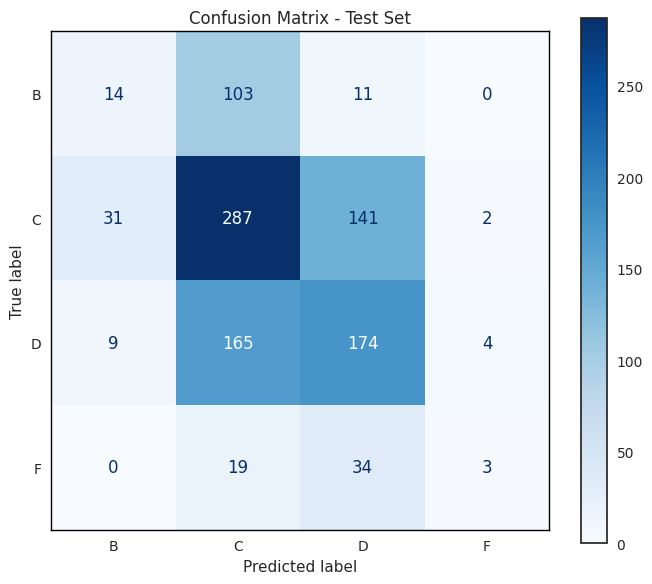

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    predictions['Grade'],
    predictions['prediction_label']
)

fig, ax = plt.subplots(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=sorted(predictions['Grade'].unique())
)

disp.plot(
    cmap='Blues',
    ax=ax,
)

ax.grid(False)

for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.savefig('confusion_matrix_pycaret_f.pdf', bbox_inches='tight')
plt.show()

In [ ]:
from sklearn.metrics import classification_report

print("Classification Report")
print(
    classification_report(
        predictions['Grade'],
        predictions['prediction_label']
    )
)

Classification Report
              precision    recall  f1-score   support

           B       0.26      0.11      0.15       128
           C       0.50      0.62      0.55       461
           D       0.48      0.49      0.49       352
           F       0.33      0.05      0.09        56

    accuracy                           0.48       997
   macro avg       0.39      0.32      0.32       997
weighted avg       0.45      0.48      0.45       997



In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

y_true = predictions['Grade']
y_pred = predictions['prediction_label']

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall   :", recall_score(y_true, y_pred, average='weighted'))
print("F1 Score :", f1_score(y_true, y_pred, average='weighted'))

Accuracy : 0.4794383149448345
Precision: 0.45384672536126897
Recall   : 0.4794383149448345
F1 Score : 0.45393398471901203



=== ANALISIS FEATURE IMPORTANCE ===

=== TOP 15 FITUR PALING BERPENGARUH ===


,Fitur,Tingkat Kepentingan
0,Midterm_Score,0.144811
1,Assignments_Avg,0.117529
2,Quizzes_Avg,0.091062
3,Participation_Score,0.085388
4,Load_Sleep_Ratio,0.062611
5,Total_Weekly_Load,0.062586
6,Study_Sleep_Ratio,0.062523
7,Sleep_Hours_per_Night,0.060513
8,Study_Hours_per_Week,0.059670
9,Stress_Level (1-10),0.043769


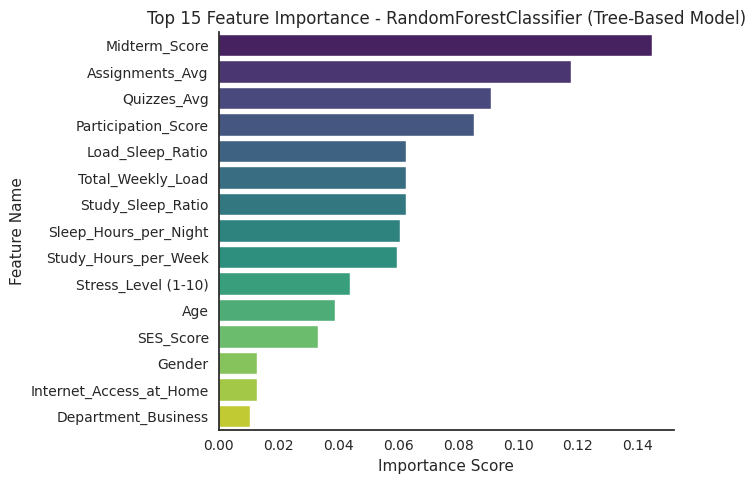

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pycaret.classification import get_config

print("\n=== ANALISIS FEATURE IMPORTANCE ===")

# Gunakan model terbaik hasil compare_models()
# Lebih aman untuk ekstraksi feature importance dibanding final_model
model_for_importance = best_model

# Ambil nilai feature importance atau koefisien
if hasattr(model_for_importance, 'feature_importances_'):
    importances = model_for_importance.feature_importances_
    title_suffix = "(Tree-Based Model)"

elif hasattr(model_for_importance, 'coef_'):
    if model_for_importance.coef_.ndim > 1:
        importances = abs(model_for_importance.coef_).mean(axis=0)
    else:
        importances = abs(model_for_importance.coef_)

    title_suffix = "(Linear Model)"

else:
    print(
        f"Model {type(model_for_importance).__name__} "
        "tidak mendukung feature importance secara langsung."
    )
    importances = None

# Jika importance tersedia
if importances is not None:

    try:
        # Mengambil nama fitur setelah preprocessing PyCaret
        feature_names = get_config('X_train_transformed').columns.tolist()

    except Exception:
        print(
            "Warning: Tidak dapat mengambil nama fitur hasil transformasi."
        )
        feature_names = [
            f"Feature_{i}"
            for i in range(len(importances))
        ]

    # Validasi jumlah fitur
    if len(feature_names) != len(importances):

        print(
            f"Jumlah feature_names ({len(feature_names)}) "
            f"tidak sama dengan jumlah importance ({len(importances)})"
        )

    else:

        # Membuat dataframe importance
        df_importance = pd.DataFrame({
            'Fitur': feature_names,
            'Tingkat Kepentingan': abs(importances)
        })

        # Urutkan dari yang paling penting
        df_importance = (
            df_importance
            .sort_values(
                by='Tingkat Kepentingan',
                ascending=False
            )
            .reset_index(drop=True)
        )

        # Tampilkan ranking
        print("\n=== TOP 15 FITUR PALING BERPENGARUH ===")
        display(df_importance.head(15))

        # Visualisasi Top 15

        plt.figure(figsize=(7, 5))

        sns.set_style("white")

        ax = sns.barplot(
            data=df_importance.head(15),
            x='Tingkat Kepentingan',
            y='Fitur',
            palette='viridis'
        )

        ax.grid(False)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        plt.title(
            f'Top 15 Feature Importance - '
            f'{type(model_for_importance).__name__} {title_suffix}'
        )

        plt.xlabel('Importance Score')
        plt.ylabel('Feature Name')

        plt.tight_layout()
        plt.savefig('feature_importance_pycaret_f.pdf')
        plt.show()